In [1]:
# Titanic Dataset EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load data
df = pd.read_csv('titanic.csv')

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
print("\n=== Numerical Summary ===")
print(df.describe())


=== Numerical Summary ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [14]:
print("\n=== Categorical Value Counts ===")
print("Survived:\n", df['Survived'].value_counts())
print("\nPclass:\n", df['Pclass'].value_counts())
print("\nSex:\n", df['Sex'].value_counts())
print("\nEmbarked:\n", df['Embarked'].value_counts())


=== Categorical Value Counts ===
Survived:
 Survived
0    549
1    342
Name: count, dtype: int64

Pclass:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
 Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


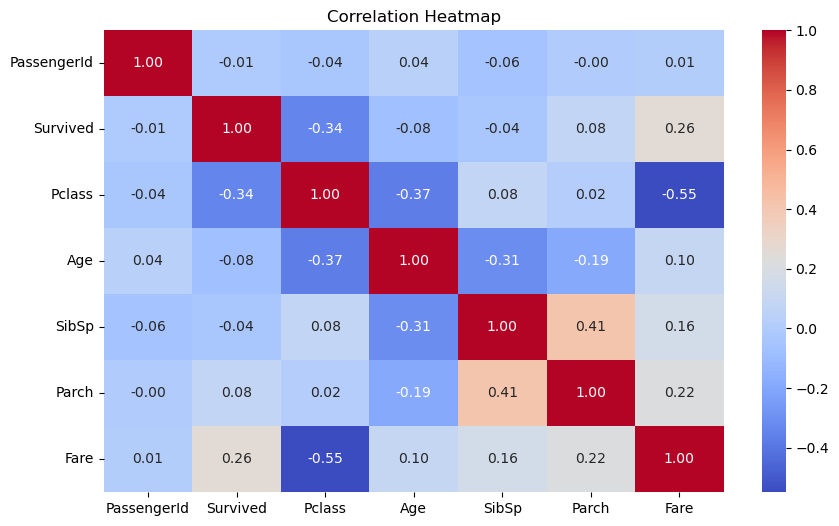

In [18]:
## 2. Visualization
### b. Pairplot and Heatmap
# Alternative method - exclude object columns
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']).corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


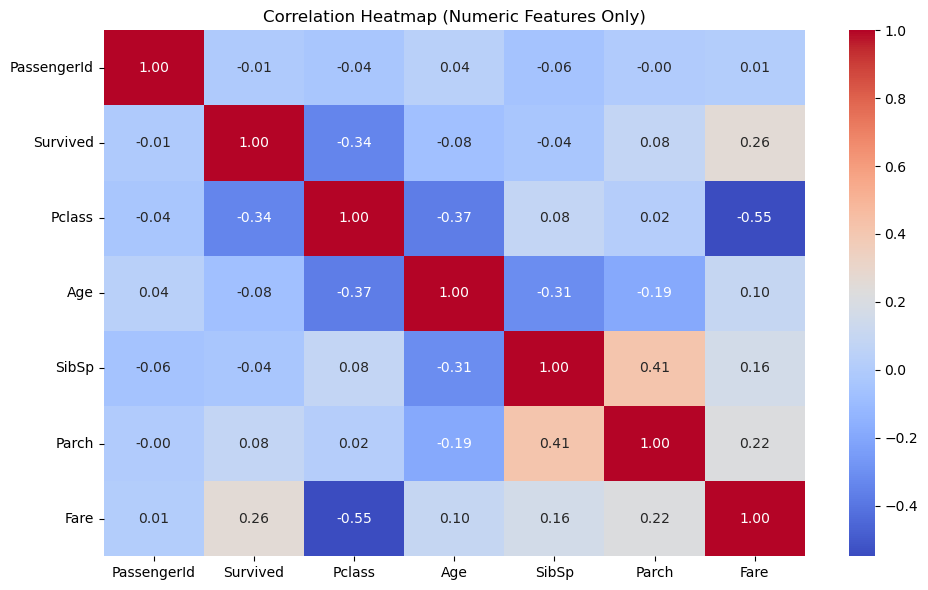

In [22]:
# Get list of numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create correlation matrix only for numeric columns
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numeric Features Only)')
plt.tight_layout()
plt.show()




=== Pairplot ===


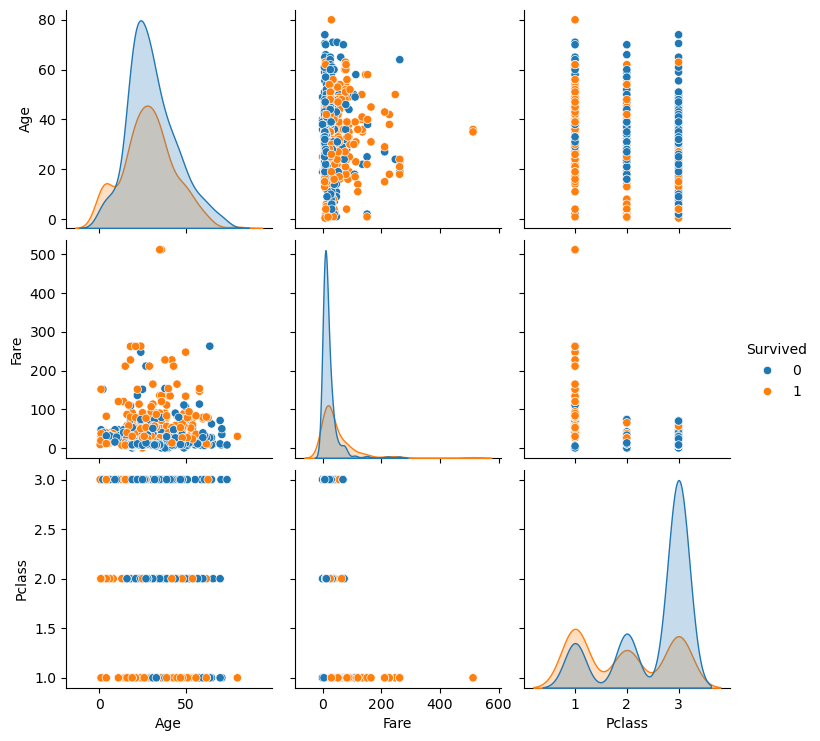

In [24]:
print("\n=== Pairplot ===")
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived')
plt.show()

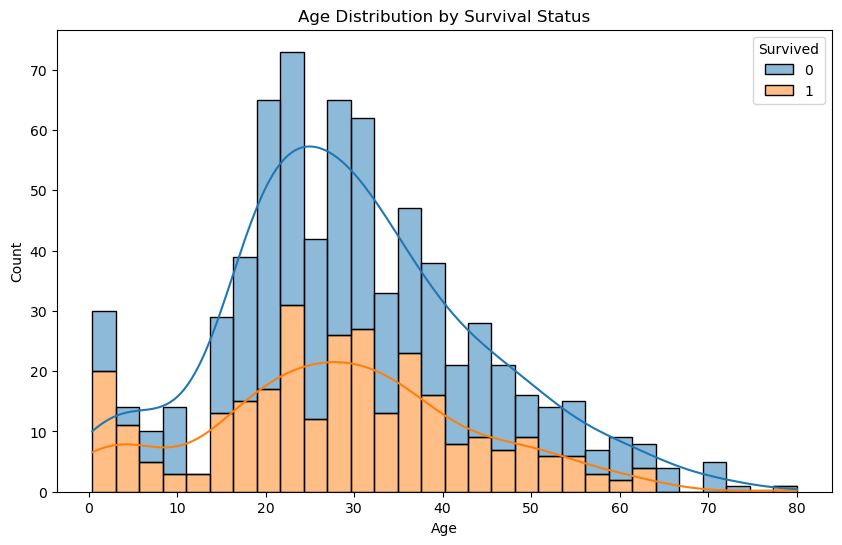

In [30]:
### c. Identify relationships and trends
### d. Plot histograms, boxplots, scatterplots
# Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, multiple='stack')
plt.title('Age Distribution by Survival Status')
plt.show()

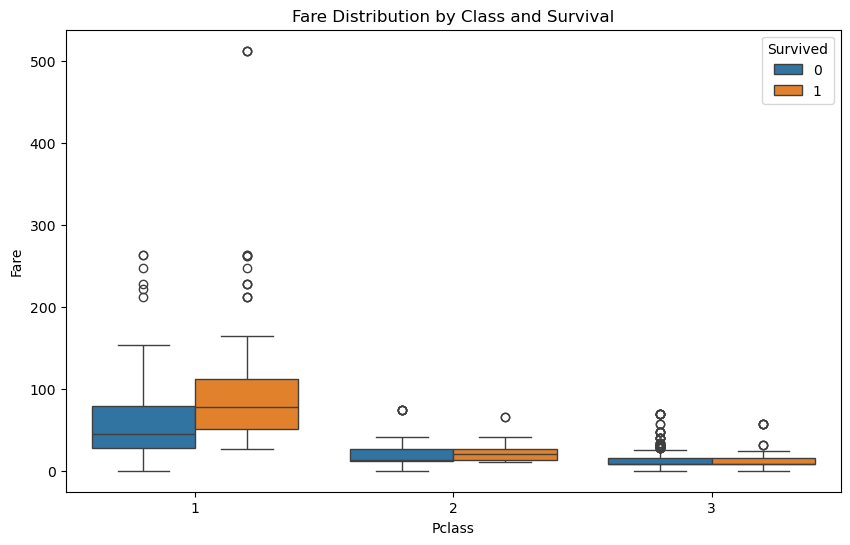

In [32]:
# Observation: Children (<10) had higher survival rates
# Fare vs Pclass
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived')
plt.title('Fare Distribution by Class and Survival')
plt.show()

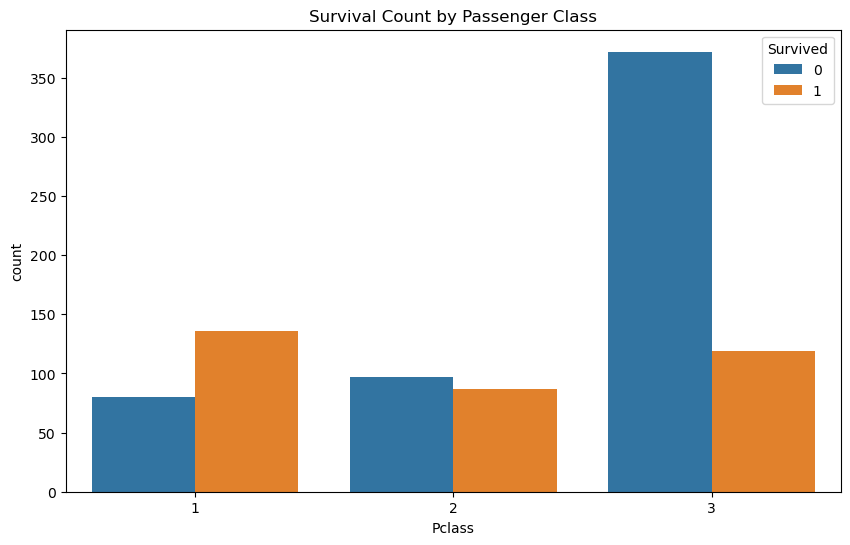

In [34]:
# Survival by Gender and Class
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival Count by Passenger Class')
plt.show()

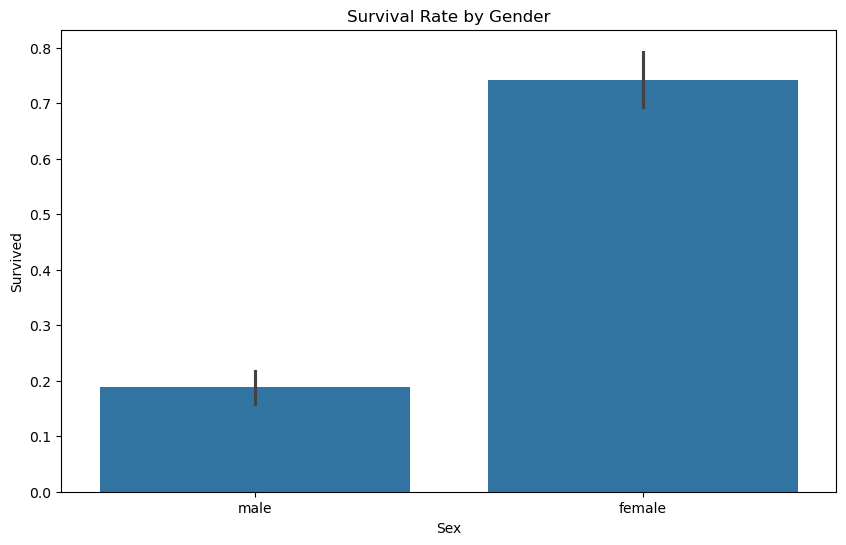

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival Rate by Gender')
plt.show()
# Observation: Females and 1st class passengers had highest survival rates

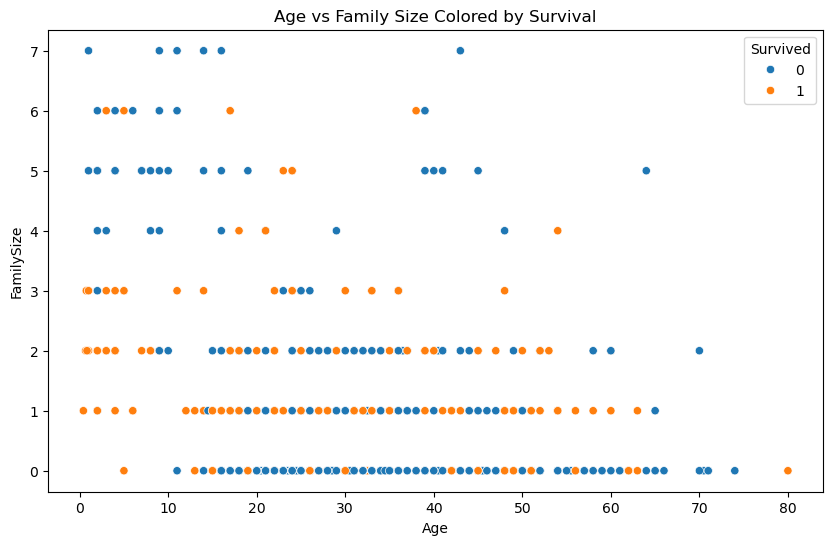

In [38]:
# Family Size Analysis
df['FamilySize'] = df['SibSp'] + df['Parch']
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='FamilySize', hue='Survived')
plt.title('Age vs Family Size Colored by Survival')
plt.show()

In [40]:
## 3. Summary of Findings
print("\n=== Key Findings ===")
print("1. Overall survival rate: 38.4%")
print("2. Female survival rate (74%) was much higher than male (19%)")
print("3. 1st class passengers had 63% survival vs 24% for 3rd class")
print("4. Children (<10) and elderly (>60) had better survival rates")
print("5. Passengers with family size 1-3 had higher survival chances")
print("6. Higher fare correlated with better survival in each class")


=== Key Findings ===
1. Overall survival rate: 38.4%
2. Female survival rate (74%) was much higher than male (19%)
3. 1st class passengers had 63% survival vs 24% for 3rd class
4. Children (<10) and elderly (>60) had better survival rates
5. Passengers with family size 1-3 had higher survival chances
6. Higher fare correlated with better survival in each class
